In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.seasonal import seasonal_decompose

In [76]:
data = pd.read_csv("AirPassengers.xls")

In [77]:
data.head(5)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [78]:
data.shape

(144, 2)

In [79]:
#convert column year in date time format (truncating to month)
data['Month'] = pd.to_datetime(data['Month'])
data = data.set_index('Month')

In [80]:
data.head(5)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [81]:
data.shape

(144, 1)

Text(0, 0.5, '#Passengers')

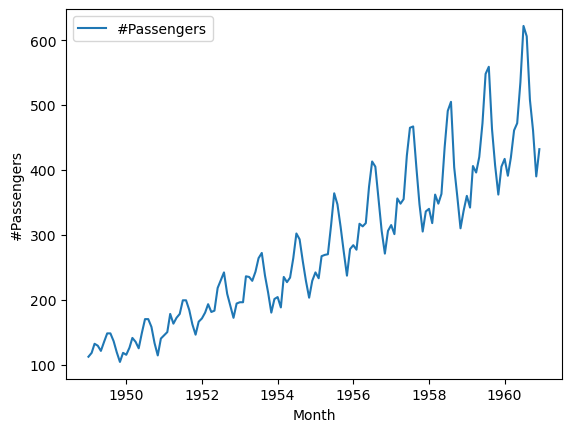

In [82]:
sns.lineplot(data)
plt.ylabel("#Passengers")

In [83]:
#we can see that the #passengers is increasing over time, with some seasonality, that is, with every year the trend id amplified.

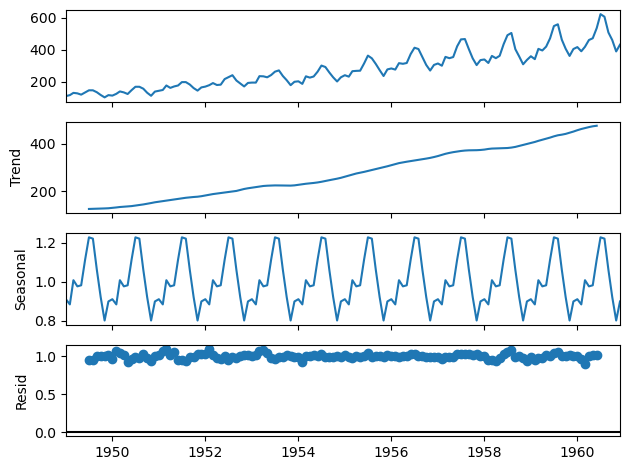

In [84]:
#decomposition of the time series - multiplicative model
result = seasonal_decompose(data[['#Passengers']], model = 'multiplicative', period = 12)
result.plot()
plt.show()

In [85]:
#pip install pymannkendall

In [86]:
import pymannkendall as mk

In [87]:
#Perform the Mann-Kendall test
#H0: There is no monotonic trend in the series

mk.original_test(data['#Passengers'])

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(14.381610025544802), Tau=np.float64(0.8087606837606838), s=np.float64(8327.0), var_s=np.float64(335164.3333333333), slope=np.float64(2.451216287678477), intercept=np.float64(90.23803543098887))

In [88]:
#Train test splitting
train_df = data[:int(data.shape[0]*0.7)]
test_df = data[int(data.shape[0]*0.7):]

In [89]:
train_df.head(5)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [90]:
#single exponential smoothing model
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(train_df)
model_single_fit = model.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [91]:
forecast_single = model_single_fit.forecast(len(test_df))
print(forecast_single)

1957-05-01    348.0
1957-06-01    348.0
1957-07-01    348.0
1957-08-01    348.0
1957-09-01    348.0
1957-10-01    348.0
1957-11-01    348.0
1957-12-01    348.0
1958-01-01    348.0
1958-02-01    348.0
1958-03-01    348.0
1958-04-01    348.0
1958-05-01    348.0
1958-06-01    348.0
1958-07-01    348.0
1958-08-01    348.0
1958-09-01    348.0
1958-10-01    348.0
1958-11-01    348.0
1958-12-01    348.0
1959-01-01    348.0
1959-02-01    348.0
1959-03-01    348.0
1959-04-01    348.0
1959-05-01    348.0
1959-06-01    348.0
1959-07-01    348.0
1959-08-01    348.0
1959-09-01    348.0
1959-10-01    348.0
1959-11-01    348.0
1959-12-01    348.0
1960-01-01    348.0
1960-02-01    348.0
1960-03-01    348.0
1960-04-01    348.0
1960-05-01    348.0
1960-06-01    348.0
1960-07-01    348.0
1960-08-01    348.0
1960-09-01    348.0
1960-10-01    348.0
1960-11-01    348.0
1960-12-01    348.0
Freq: MS, dtype: float64


In [92]:
model_single_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

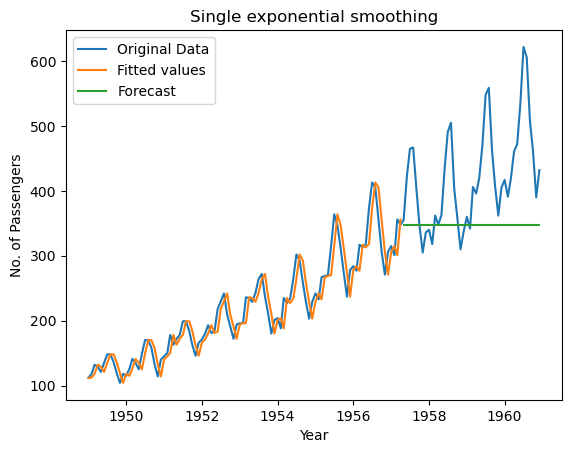

In [93]:
plt.plot(data, label ="Original Data")
plt.plot(model_single_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_single, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("No. of Passengers")
plt.title("Single exponential smoothing")
plt.legend()
plt.show()

In [94]:
#DOUBLE EXPONENETIAL SMOOTHING (Holt's model)

In [95]:
from statsmodels.tsa.api import Holt

In [96]:
model_double = Holt(train_df)
model_double_fit = model_double.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [97]:
forecast_double = model_double_fit.forecast(len(test_df))
print(forecast_double)

1957-05-01    352.234329
1957-06-01    356.468659
1957-07-01    360.702988
1957-08-01    364.937317
1957-09-01    369.171647
1957-10-01    373.405976
1957-11-01    377.640305
1957-12-01    381.874635
1958-01-01    386.108964
1958-02-01    390.343293
1958-03-01    394.577623
1958-04-01    398.811952
1958-05-01    403.046281
1958-06-01    407.280610
1958-07-01    411.514940
1958-08-01    415.749269
1958-09-01    419.983598
1958-10-01    424.217928
1958-11-01    428.452257
1958-12-01    432.686586
1959-01-01    436.920916
1959-02-01    441.155245
1959-03-01    445.389574
1959-04-01    449.623903
1959-05-01    453.858233
1959-06-01    458.092562
1959-07-01    462.326891
1959-08-01    466.561221
1959-09-01    470.795550
1959-10-01    475.029879
1959-11-01    479.264209
1959-12-01    483.498538
1960-01-01    487.732867
1960-02-01    491.967196
1960-03-01    496.201526
1960-04-01    500.435855
1960-05-01    504.670184
1960-06-01    508.904514
1960-07-01    513.138843
1960-08-01    517.373172


In [98]:
model_double_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(0.006851678312691752),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(6.0),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

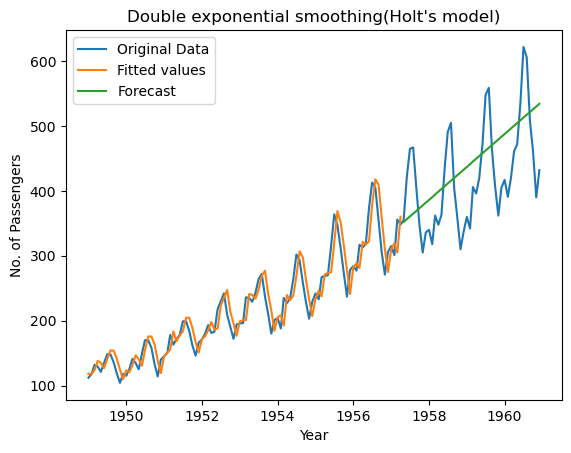

In [99]:
plt.plot(data, label ="Original Data")
plt.plot(model_double_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_double, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("No. of Passengers")
plt.title("Double exponential smoothing(Holt's model)")
plt.legend()
plt.show()

In [100]:
#TRIPLE EXPONENTIAL SMOOTHING (HOLT_WINTER'S MODEL)
from statsmodels.tsa.api import ExponentialSmoothing

In [101]:
model_triple = ExponentialSmoothing(train_df, seasonal_periods = 12, trend = "add", seasonal = "add") #from the pegel's chart, since it looks similar to the additive-addititve model, therefore both trend and seasonality have been taken as additive
model_triple_fit = model_triple.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [102]:
#from the pegel's chart, since it looks similar to the additive-addititve model, therefore both trend and seasonality have been taken as additive
#can be done using either which we think is closest which we find more accurate

In [103]:
model_triple_fit.params

{'smoothing_level': np.float64(0.25502063857890783),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.7449793614210922),
 'damping_trend': nan,
 'initial_level': np.float64(118.7944419228827),
 'initial_trend': np.float64(2.32515869420161),
 'initial_seasons': array([ -9.11869393,  -3.516225  ,   8.96158317,   3.69182099,
         -5.06940065,   9.03382306,  21.24896472,  18.82131432,
          4.68850474, -14.11820695, -28.56012346, -11.95146413]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [104]:
forecast_triple = model_triple_fit.forecast(len(test_df))
print(forecast_triple)

1957-05-01    351.239579
1957-06-01    403.308277
1957-07-01    439.937054
1957-08-01    426.800189
1957-09-01    375.973335
1957-10-01    329.109742
1957-11-01    295.901180
1957-12-01    333.331609
1958-01-01    343.405584
1958-02-01    331.809495
1958-03-01    384.455531
1958-04-01    374.284622
1958-05-01    379.141484
1958-06-01    431.210181
1958-07-01    467.838958
1958-08-01    454.702093
1958-09-01    403.875240
1958-10-01    357.011646
1958-11-01    323.803084
1958-12-01    361.233513
1959-01-01    371.307488
1959-02-01    359.711399
1959-03-01    412.357435
1959-04-01    402.186526
1959-05-01    407.043388
1959-06-01    459.112085
1959-07-01    495.740863
1959-08-01    482.603997
1959-09-01    431.777144
1959-10-01    384.913551
1959-11-01    351.704988
1959-12-01    389.135417
1960-01-01    399.209392
1960-02-01    387.613303
1960-03-01    440.259340
1960-04-01    430.088430
1960-05-01    434.945292
1960-06-01    487.013990
1960-07-01    523.642767
1960-08-01    510.505902


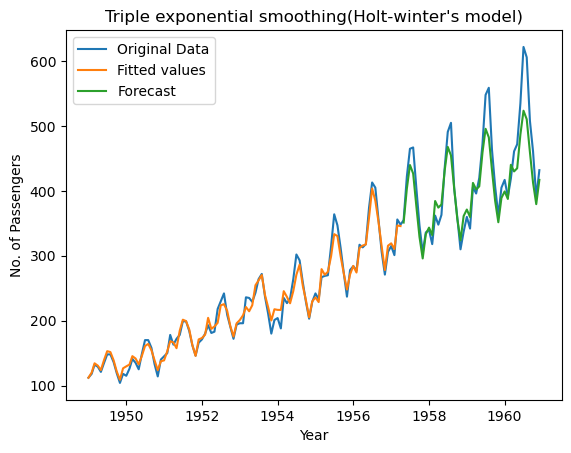

In [105]:
plt.plot(data, label ="Original Data")
plt.plot(model_triple_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_triple, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("No. of Passengers")
plt.title("Triple exponential smoothing(Holt-winter's model)")
plt.legend()
plt.show()

In [106]:
#using add-multi model
model_triple_mul = ExponentialSmoothing(train_df, seasonal_periods = 12, trend = "add", seasonal = "mul")

model_triple_fit_mul = model_triple_mul.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [107]:
model_triple_fit_mul.params

{'smoothing_level': np.float64(0.7295713318153096),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': nan,
 'initial_level': np.float64(124.6649199028986),
 'initial_trend': np.float64(2.290257368024071),
 'initial_seasons': array([0.89282037, 0.86706945, 0.99987366, 0.96735903, 0.96030482,
        1.08328738, 1.19721583, 1.17160007, 1.02967704, 0.89443356,
        0.77733482, 0.87878758]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [108]:
forecast_triple_mul = model_triple_fit_mul.forecast(len(test_df))
print(forecast_triple_mul)

1957-05-01    346.974158
1957-06-01    393.890813
1957-07-01    438.057922
1957-08-01    431.368454
1957-09-01    381.472398
1957-10-01    333.416185
1957-11-01    291.545823
1957-12-01    331.609164
1958-01-01    338.949205
1958-02-01    331.158973
1958-03-01    384.170720
1958-04-01    373.893474
1958-05-01    373.366300
1958-06-01    423.662896
1958-07-01    470.961111
1958-08-01    463.567642
1958-09-01    409.771103
1958-10-01    357.997981
1958-11-01    312.909384
1958-12-01    355.760961
1959-01-01    363.486666
1959-02-01    354.988719
1959-03-01    411.650336
1959-04-01    400.479488
1959-05-01    399.758442
1959-06-01    453.434979
1959-07-01    503.864299
1959-08-01    495.766831
1959-09-01    438.069808
1959-10-01    382.579778
1959-11-01    334.272946
1959-12-01    379.912757
1960-01-01    388.024128
1960-02-01    378.818466
1960-03-01    439.129953
1960-04-01    427.065502
1960-05-01    426.150585
1960-06-01    483.207062
1960-07-01    536.767488
1960-08-01    527.966019


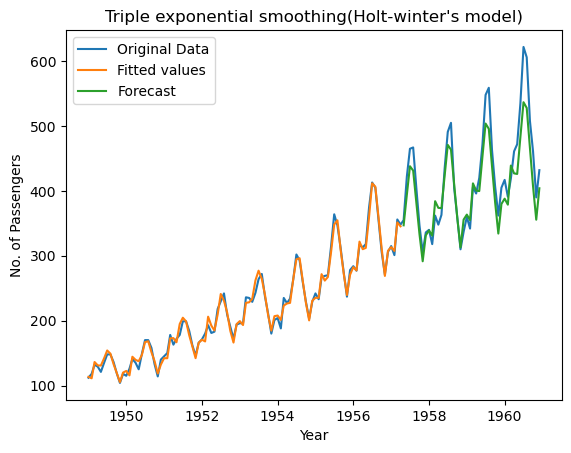

In [109]:
plt.plot(data, label ="Original Data")
plt.plot(model_triple_fit_mul.fittedvalues, label= "Fitted values")
plt.plot(forecast_triple_mul, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("No. of Passengers")
plt.title("Triple exponential smoothing(Holt-winter's model)")
plt.legend()
plt.show()

In [110]:
#testing for the accuracy of the two models

In [111]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [112]:
mape_test_add = mean_absolute_percentage_error(test_df['#Passengers'], forecast_triple)
print("MAPE Test for Test Data:",mape_test_add)

MAPE Test for Test Data: 0.053971281128541035


In [113]:
mape_test_mul = mean_absolute_percentage_error(test_df['#Passengers'], forecast_triple_mul)
print("MAPE Test for Test Data:",mape_test_mul)

MAPE Test for Test Data: 0.05580208531487156


In [114]:
#ADF Test
#H0: Series is not stationary, ie,e series has a unit root
#H1: Series is stationary, ie,e series has no unit root

In [115]:
from statsmodels.tsa.stattools import adfuller 
result = adfuller(data['#Passengers'])

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: 0.8153688792060511
p-value: 0.991880243437641


In [116]:
#p-value > 0.05: fail to reject to H0, i.e, series is not stationary

In [117]:
#KPSS Test
#H0: Series is trend stationary, ie,e series has no unit root
#H1: Series is non-stationary, ie,e series has a unit root

In [118]:
##It is very specific to trend (KPSS)

In [119]:
from statsmodels.tsa.stattools import kpss
kp = kpss(data['#Passengers'])
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.01


C:\Users\tejas\AppData\Local\Temp\ipykernel_24340\3925117820.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(data['#Passengers'])


In [120]:
#p-value = 0.01 < 0.05: Reject HO, ie., series is non stationary

In [121]:
#Here, Since both the condition is not satisfied, therefore we conclude that the series is NOT stationarity.

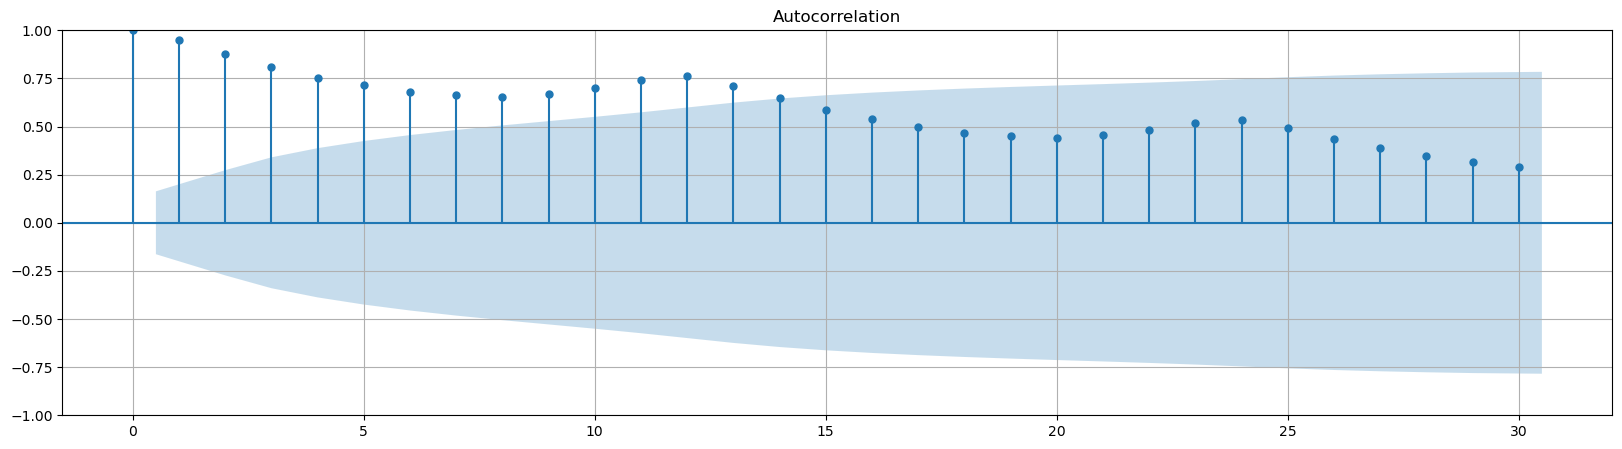

In [122]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(data['#Passengers'], ax = plt.gca(), lags = 30)
plt.show()

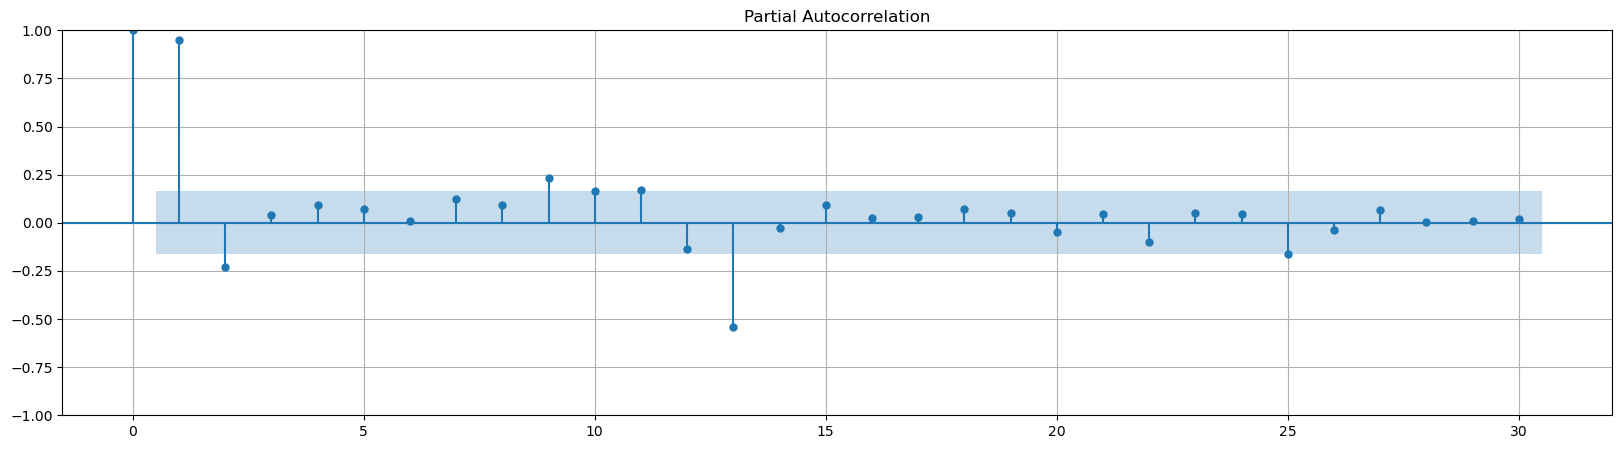

In [123]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(data['#Passengers'], ax = plt.gca(), lags = 30)
plt.show()

In [124]:
#To make the series stationary we now do differencing

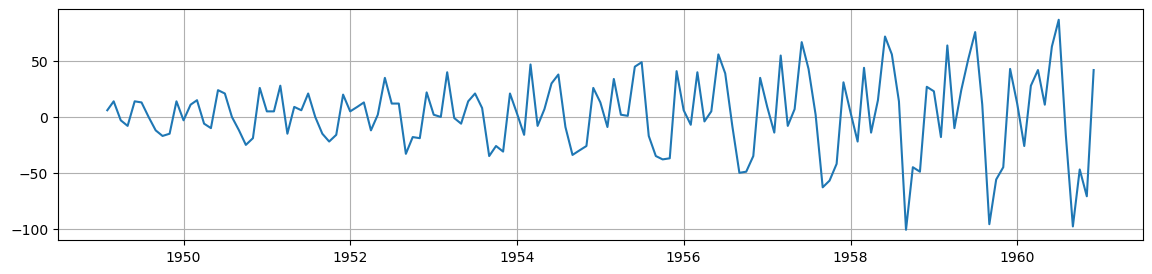

In [125]:
#NON Seasonal differencing
diff = data['#Passengers'].diff().dropna()
plt.figure(figsize = (14,3))  #making trend data stationary
plt.grid()
plt.plot(diff)
plt.show()

In [126]:
from statsmodels.tsa.stattools import adfuller 
result = adfuller(diff)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -2.8292668241699874
p-value: 0.05421329028382711


In [127]:
#Since, p-value < 0.05, reject HO, therfore the stationary is stationary.

In [128]:
#KPSS Test 
from statsmodels.tsa.stattools import kpss
kp = kpss(diff)
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.1


C:\Users\tejas\AppData\Local\Temp\ipykernel_24340\1400596546.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff)


In [129]:
#p-value < 0.05, do not reject HO, ie., data has become trend stationary

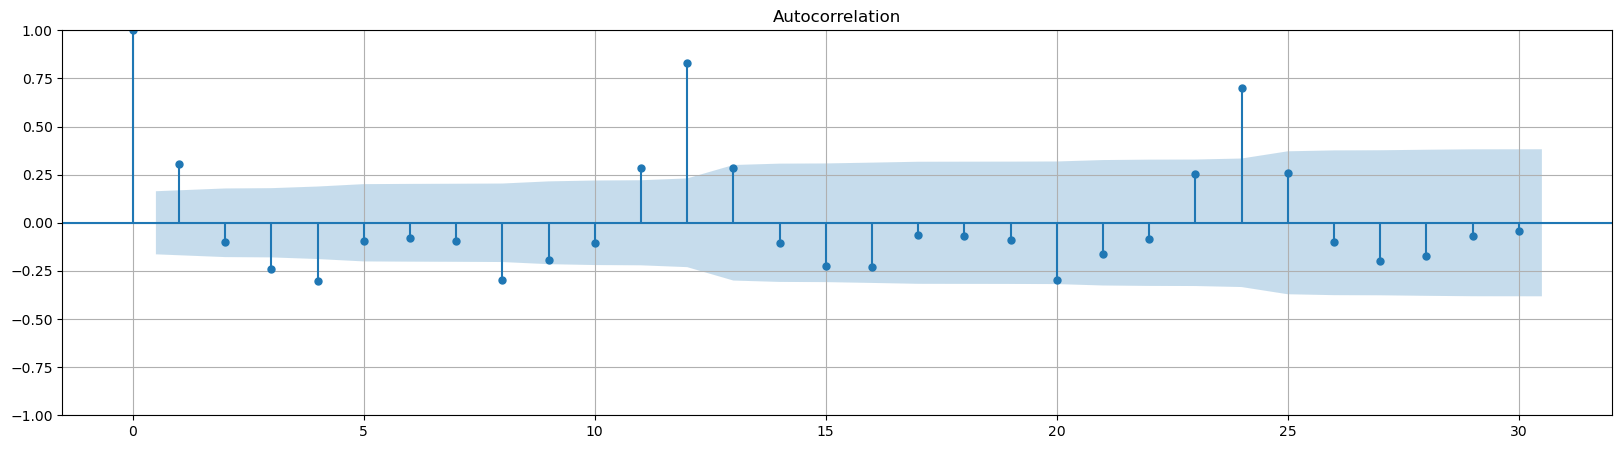

In [130]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(diff, ax = plt.gca(), lags = 30)
plt.show()

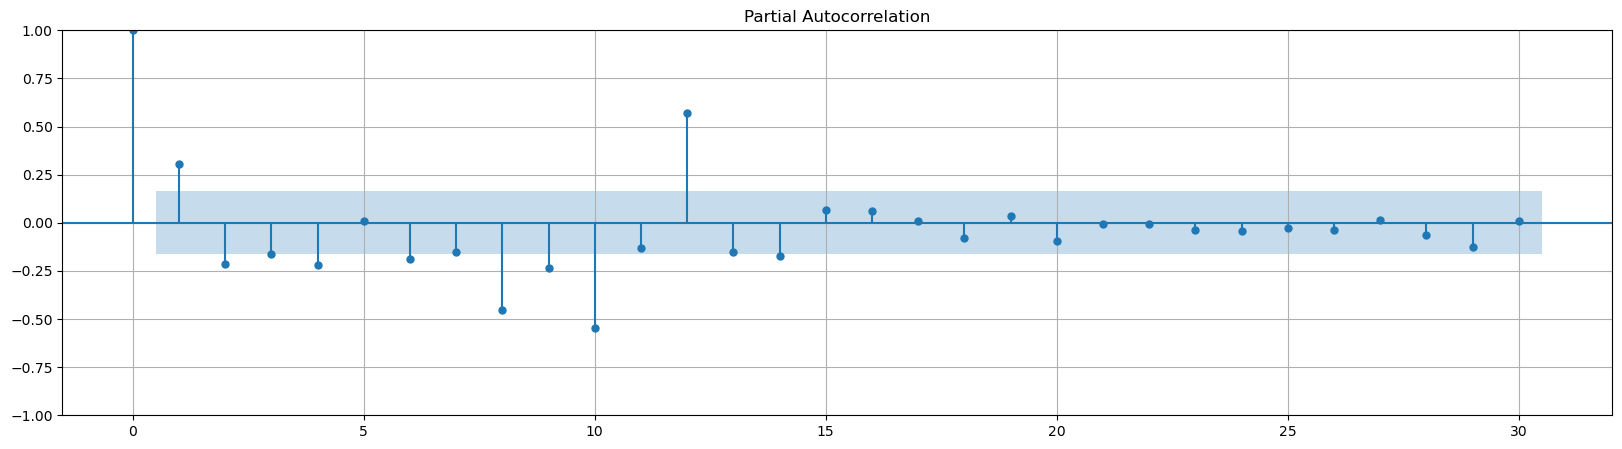

In [131]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(diff, ax = plt.gca(), lags = 30)
plt.show()

In [132]:
#according to the plots the series has yet not become stationary.

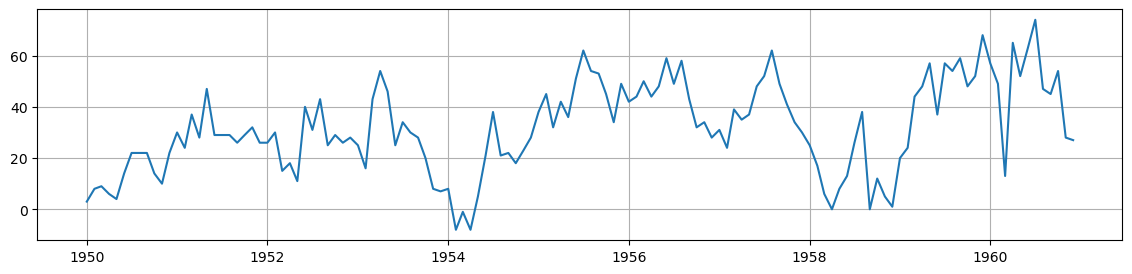

In [133]:
#Seasonal differencing
sdiff = data['#Passengers'].diff(periods = 12).dropna()
plt.figure(figsize = (14,3))  #making trend data stationary
plt.grid()
plt.plot(sdiff)
plt.show()

In [134]:
#ADF test
from statsmodels.tsa.stattools import adfuller 
result = adfuller(sdiff)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -3.3830207264924796
p-value: 0.011551493085515008


In [135]:
#p-value<0.05, reject HO, series is stationary

In [136]:
#KPSS Test
#KPSS Test 
from statsmodels.tsa.stattools import kpss
kp = kpss(sdiff)
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.03409999422360403


In [137]:
#p-value < 0.05, reject H0, which means the series is not stationary(trend).

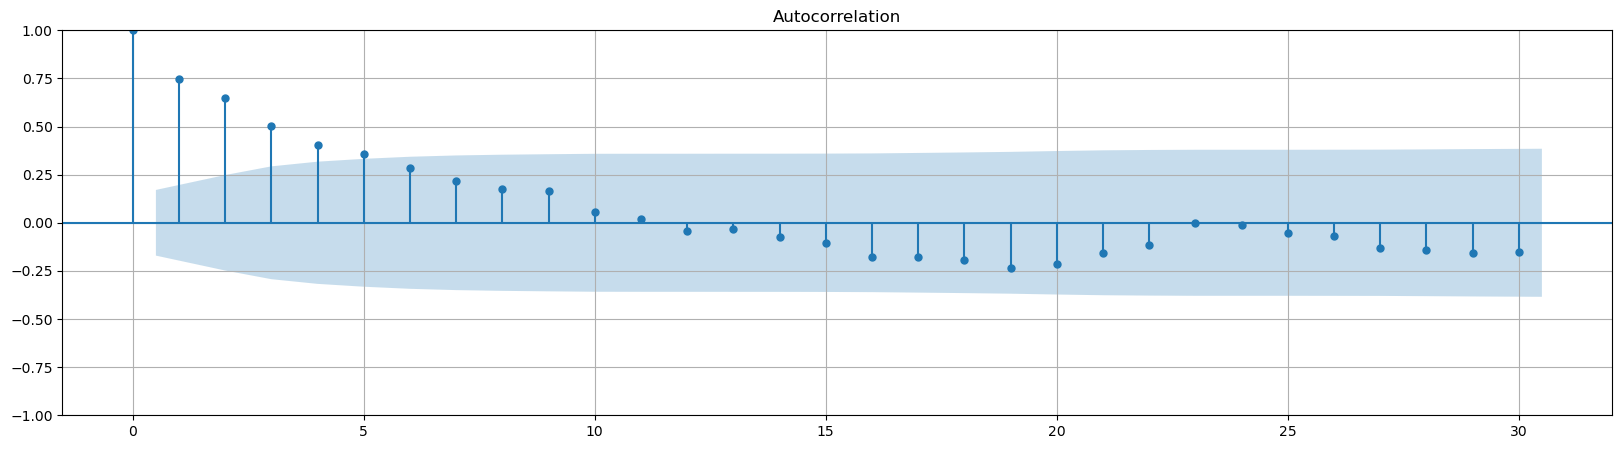

In [138]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(sdiff, ax = plt.gca(), lags = 30)
plt.show()

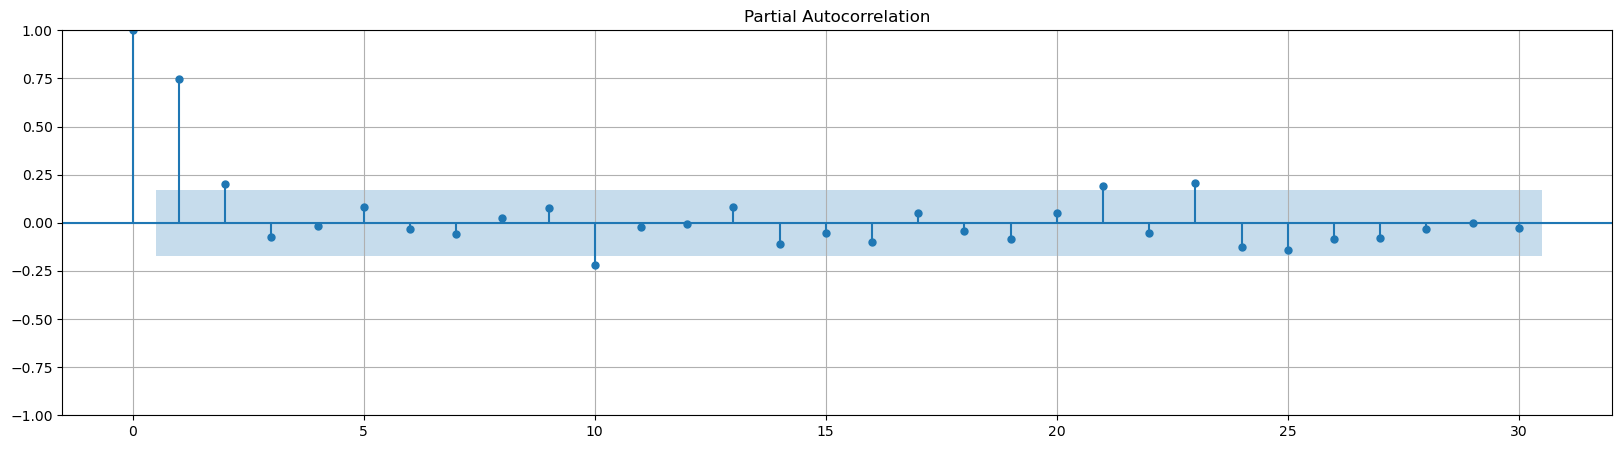

In [139]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(sdiff, ax = plt.gca(), lags = 30)
plt.show()

In [140]:
#Still not stationary

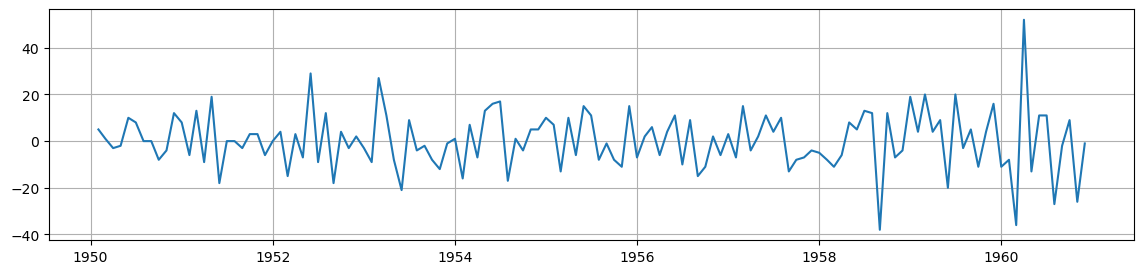

In [141]:
#SEASONAL AND NON SEASONAL DIFFERNECING
sddiff = sdiff.diff().dropna() #Non seasonal differencing on the seasonal differenced series
plt.figure(figsize = (14,3))
plt.grid()
plt.plot(sddiff)

plt.show()

In [142]:
#ADF test
from statsmodels.tsa.stattools import adfuller 
result = adfuller(sddiff)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -15.595618083746338
p-value: 1.856511600123444e-28


In [143]:
#Series is stationary

In [144]:
#KPSS Test
#KPSS Test 
from statsmodels.tsa.stattools import kpss
kp = kpss(sddiff)
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.1


C:\Users\tejas\AppData\Local\Temp\ipykernel_24340\3216409577.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sddiff)


In [145]:
#Series is trend stationary (p>0.05)

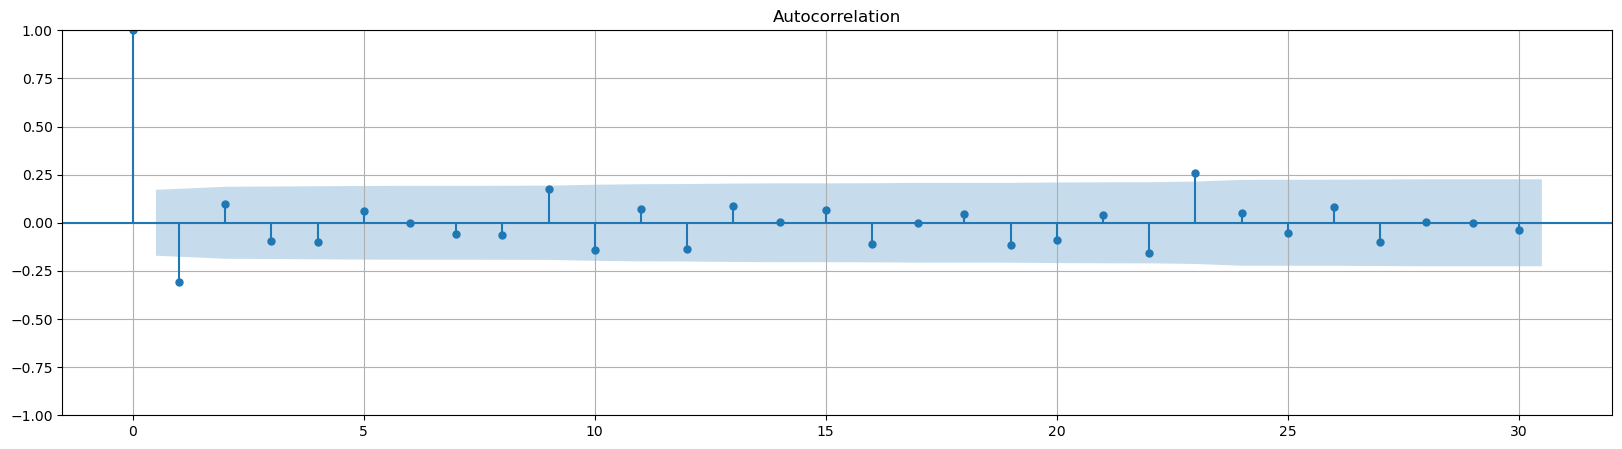

In [146]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_acf(sddiff, ax = plt.gca(), lags = 30)
plt.show()

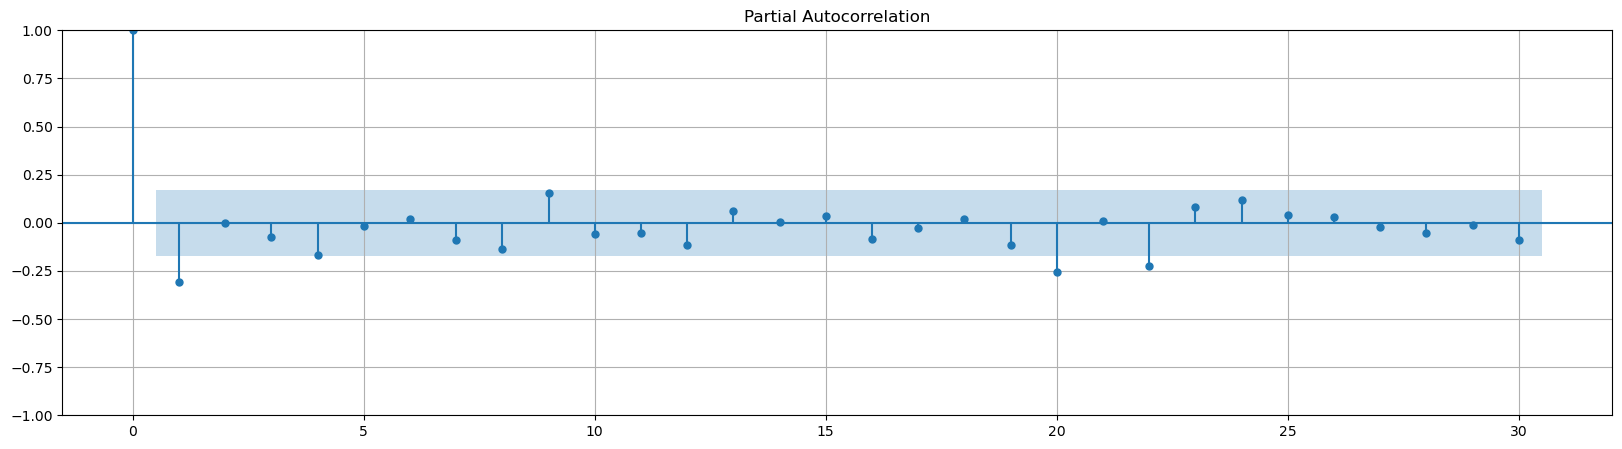

In [147]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (20,5))
plt.grid()
plot_pacf(sddiff, ax = plt.gca(), lags = 30)
plt.show()

In [148]:
#We finally have confirmed that the series is now stationary, via plots as well as tests.